# PROCESAMIENTO DE TEXTOS - Dataset TFM
## Sistema de Asistencia Lectura para Discapacidad Cognitiva
**Cristina Varela - IABD**

---

**Objetivo:** Procesar archivos .txt y generar dataset ampliado con ~70-100 textos etiquetados.

**Input:** 
- 24 archivos .txt organizados en carpetas por nivel

**Output:**
- CSV con 70-100 fragmentos de texto etiquetados
- Clasificador re-entrenado con mejor accuracy

## 1. Importar Librerías

In [1]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Configuración de Rutas



In [2]:
# Ruta base del proyecto
BASE_DIR = Path(r'C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad')

# Rutas de carpetas con archivos .txt (ajusta según tu estructura)
CARPETAS_TEXTOS = {
    1: BASE_DIR / 'data' / 'raw' / 'nivel_1_lectura_facil',  # Plena Inclusión
    2: BASE_DIR / 'data' / 'raw' / 'nivel_2_cuentos_simple',  # Cuentos simples/fábulas
    3: BASE_DIR / 'data' / 'raw' / 'nivel_3_cuentos_complejo',  # Cuentos complejos
    4: BASE_DIR / 'data' / 'raw' / 'nivel_4_narrativo_adulto',  # Novelas nivel 4
    5: BASE_DIR / 'data' / 'raw' / 'nivel_5_tecnico_especializado',  # Recetas y textos técnicos
}

# Archivo CSV de salida
OUTPUT_CSV = BASE_DIR / 'data' / 'processed' / 'textos_etiquetados.csv'

print(f"✓ Configuración de rutas establecida")
print(f"  Base: {BASE_DIR}")
print(f"  Output: {OUTPUT_CSV}")

✓ Configuración de rutas establecida
  Base: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad
  Output: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad\data\processed\textos_etiquetados.csv


## 3. Funciones de Procesamiento

In [3]:
def limpiar_texto(texto):
    """
    Limpia el texto eliminando metadata, líneas vacías y caracteres especiales.
    """
    # Eliminar líneas comunes de metadata
    lineas_eliminar = [
        'Escuchar el texto',
        'Publicado el',
        'Guardado en',
        'Ver la versión',
        'Twitter',
        'Facebook',
        'Telegram',
        'WhatsApp',
    ]
    
    lineas = texto.split('\n')
    lineas_limpias = []
    
    for linea in lineas:
        linea = linea.strip()
        
        # Saltar líneas vacías o muy cortas
        if len(linea) < 10:
            continue
            
        # Saltar líneas de metadata
        if any(meta in linea for meta in lineas_eliminar):
            continue
            
        lineas_limpias.append(linea)
    
    texto_limpio = ' '.join(lineas_limpias)
    
    # Limpiar espacios múltiples
    texto_limpio = re.sub(r'\s+', ' ', texto_limpio)
    
    return texto_limpio.strip()


def dividir_en_fragmentos(texto, min_palabras=25, max_palabras=50):
    """
    Divide un texto en fragmentos de 2-3 frases (20-60 palabras).
    """
    # Dividir en frases
    frases = re.split(r'[.!?]+', texto)
    frases = [f.strip() for f in frases if f.strip()]
    
    fragmentos = []
    fragmento_actual = []
    palabras_actual = 0
    
    for frase in frases:
        num_palabras = len(frase.split())
        
        # Si añadir esta frase excede el máximo, guardar fragmento actual
        if palabras_actual + num_palabras > max_palabras and fragmento_actual:
            fragmentos.append(' '.join(fragmento_actual) + '.')
            fragmento_actual = [frase]
            palabras_actual = num_palabras
        else:
            fragmento_actual.append(frase)
            palabras_actual += num_palabras
        
        # Si alcanzamos el mínimo de palabras, podemos cerrar el fragmento
        if palabras_actual >= min_palabras and len(fragmento_actual) >= 2:
            fragmentos.append(' '.join(fragmento_actual) + '.')
            fragmento_actual = []
            palabras_actual = 0
    
    # Añadir último fragmento si tiene suficientes palabras
    if fragmento_actual and palabras_actual >= min_palabras:
        fragmentos.append(' '.join(fragmento_actual) + '.')
    
    return fragmentos


def procesar_archivo(filepath, nivel):
    """
    Procesa un archivo .txt y devuelve lista de fragmentos con su nivel.
    """
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            texto = f.read()
    except UnicodeDecodeError:
        # Intentar con otra codificación
        with open(filepath, 'r', encoding='latin-1') as f:
            texto = f.read()
    
    # Limpiar texto
    texto_limpio = limpiar_texto(texto)
    
    if not texto_limpio:
        return []
    
    # Dividir en fragmentos
    fragmentos = dividir_en_fragmentos(texto_limpio)
    
    # Crear registros
    registros = []
    for i, fragmento in enumerate(fragmentos):
        if len(fragmento.split()) >= 12:  # Mínimo 15 palabras
            registros.append({
                'texto': fragmento,
                'nivel': nivel,
                'fuente': filepath.name,
                'fragmento_num': i+1
            })
    
    return registros

print("✓ Funciones de procesamiento definidas")

✓ Funciones de procesamiento definidas


In [4]:
todos_los_textos = []
stats = {}

print("Procesando archivos...\n")

for nivel, carpeta in CARPETAS_TEXTOS.items():
    if not carpeta.exists():
        print(f"⚠️  Carpeta no encontrada (nivel {nivel}): {carpeta}")
        print(f"   Saltando...\n")
        continue
    
    archivos_txt = list(carpeta.glob('*.txt'))
    
    if not archivos_txt:
        print(f"⚠️  No hay archivos .txt en nivel {nivel}: {carpeta}")
        continue
    
    print(f"📁 Nivel {nivel}: {carpeta.name}")
    print(f"   Archivos encontrados: {len(archivos_txt)}")
    
    fragmentos_nivel = 0
    
    for archivo in archivos_txt:
        registros = procesar_archivo(archivo, nivel)
        todos_los_textos.extend(registros)
        fragmentos_nivel += len(registros)
        print(f"   ✓ {archivo.name}: {len(registros)} fragmentos")
    
    stats[nivel] = fragmentos_nivel
    print(f"   Total nivel {nivel}: {fragmentos_nivel} fragmentos\n")

print("=" * 60)
print(f"✓ PROCESAMIENTO COMPLETADO")
print(f"  Total fragmentos: {len(todos_los_textos)}")
print("\nDistribución por nivel:")
for nivel, count in sorted(stats.items()):
    print(f"  Nivel {nivel}: {count} textos")
print("=" * 60)

Procesando archivos...

📁 Nivel 1: nivel_1_lectura_facil
   Archivos encontrados: 29
   ✓ cuento_tino_colegio.txt: 9 fragmentos
   ✓ escuela_monstruos_02_iguales_especiales.txt: 8 fragmentos
   ✓ escuela_monstruos_03_liada_mermelada.txt: 7 fragmentos
   ✓ escuela_monstruos_04_grandes_pinreles.txt: 6 fragmentos
   ✓ escuela_monstruos_05_pasteles_voladores.txt: 7 fragmentos
   ✓ escuela_monstruos_06_trastadas_aladas.txt: 8 fragmentos
   ✓ escuela_monstruos_07_pedros_truenos.txt: 8 fragmentos
   ✓ escuela_monstruos_08_emociones_colores.txt: 8 fragmentos
   ✓ escuela_monstruos_09_torpón_bonachon.txt: 8 fragmentos
   ✓ escuela_monstruos_10_helado_deshago.txt: 8 fragmentos
   ✓ escuela_monstruos_12_idea_ruedas.txt: 8 fragmentos
   ✓ escuela_monstruos_13_artista_pista.txt: 8 fragmentos
   ✓ escuela_monstruos_14_apestoso_delicioso.txt: 8 fragmentos
   ✓ escuela_monstruos_15_cuidado_enfado.txt: 8 fragmentos
   ✓ escuela_monstruos_16_rocas_graciosas.txt: 8 fragmentos
   ✓ escuela_monstruos_17_di

## 4. Procesar textos

In [5]:
todos_los_textos = []
stats = {}

print("Procesando archivos...\n")

for nivel, carpeta in CARPETAS_TEXTOS.items():
    if not carpeta.exists():
        print(f"⚠️  Carpeta no encontrada (nivel {nivel}): {carpeta}")
        print(f"   Saltando...\n")
        continue
    
    archivos_txt = list(carpeta.glob('*.txt'))
    
    if not archivos_txt:
        print(f"⚠️  No hay archivos .txt en nivel {nivel}: {carpeta}")
        continue
    
    print(f"📁 Nivel {nivel}: {carpeta.name}")
    print(f"   Archivos encontrados: {len(archivos_txt)}")
    
    fragmentos_nivel = 0
    
    for archivo in archivos_txt:
        registros = procesar_archivo(archivo, nivel)
        todos_los_textos.extend(registros)
        fragmentos_nivel += len(registros)
        print(f"   ✓ {archivo.name}: {len(registros)} fragmentos")
    
    stats[nivel] = fragmentos_nivel
    print(f"   Total nivel {nivel}: {fragmentos_nivel} fragmentos\n")

print("=" * 60)
print(f"✓ PROCESAMIENTO COMPLETADO")
print(f"  Total fragmentos: {len(todos_los_textos)}")
print("\nDistribución por nivel:")
for nivel, count in sorted(stats.items()):
    print(f"  Nivel {nivel}: {count} textos")
print("=" * 60)

Procesando archivos...

📁 Nivel 1: nivel_1_lectura_facil
   Archivos encontrados: 29
   ✓ cuento_tino_colegio.txt: 9 fragmentos
   ✓ escuela_monstruos_02_iguales_especiales.txt: 8 fragmentos
   ✓ escuela_monstruos_03_liada_mermelada.txt: 7 fragmentos
   ✓ escuela_monstruos_04_grandes_pinreles.txt: 6 fragmentos
   ✓ escuela_monstruos_05_pasteles_voladores.txt: 7 fragmentos
   ✓ escuela_monstruos_06_trastadas_aladas.txt: 8 fragmentos
   ✓ escuela_monstruos_07_pedros_truenos.txt: 8 fragmentos
   ✓ escuela_monstruos_08_emociones_colores.txt: 8 fragmentos
   ✓ escuela_monstruos_09_torpón_bonachon.txt: 8 fragmentos
   ✓ escuela_monstruos_10_helado_deshago.txt: 8 fragmentos
   ✓ escuela_monstruos_12_idea_ruedas.txt: 8 fragmentos
   ✓ escuela_monstruos_13_artista_pista.txt: 8 fragmentos
   ✓ escuela_monstruos_14_apestoso_delicioso.txt: 8 fragmentos
   ✓ escuela_monstruos_15_cuidado_enfado.txt: 8 fragmentos
   ✓ escuela_monstruos_16_rocas_graciosas.txt: 8 fragmentos
   ✓ escuela_monstruos_17_di

## 5. Crear DataFrame y Visualizar

In [6]:
# Crear DataFrame
df = pd.DataFrame(todos_los_textos)

print(f"Dataset creado: {len(df)} textos")
print(f"\nPrimeros 5 registros:")
df.head()

Dataset creado: 2151 textos

Primeros 5 registros:


,texto,nivel,fuente,fragmento_num
0,Tino va al colegio Francesco Altan Tino sale d...,1,cuento_tino_colegio.txt,1
1,Tino corre porque llega tarde Tropieza con una...,1,cuento_tino_colegio.txt,2
2,La cartera se cae al río y el agua se la lleva...,1,cuento_tino_colegio.txt,3
3,Coge la caña de pescar y espera a que pase la ...,1,cuento_tino_colegio.txt,4
4,Con un poco de esfuerzo la saca del río En la ...,1,cuento_tino_colegio.txt,5


In [7]:
# Estadísticas del dataset
print("\n📊 ESTADÍSTICAS DEL DATASET")
print("=" * 60)
print(f"Total de textos: {len(df)}")
print(f"\nDistribución por nivel:")
print(df['nivel'].value_counts().sort_index())
print(f"\nLongitud promedio (palabras):")
df['num_palabras'] = df['texto'].apply(lambda x: len(x.split()))
print(df.groupby('nivel')['num_palabras'].agg(['mean', 'min', 'max']).round(1))


📊 ESTADÍSTICAS DEL DATASET
Total de textos: 2151

Distribución por nivel:
nivel
1    215
2    519
3    299
4    542
5    576
Name: count, dtype: int64

Longitud promedio (palabras):
       mean  min  max
nivel                
1      31.1   25   48
2      33.5   14   73
3      36.0   15   73
4      34.5   12   90
5      36.6   12  103


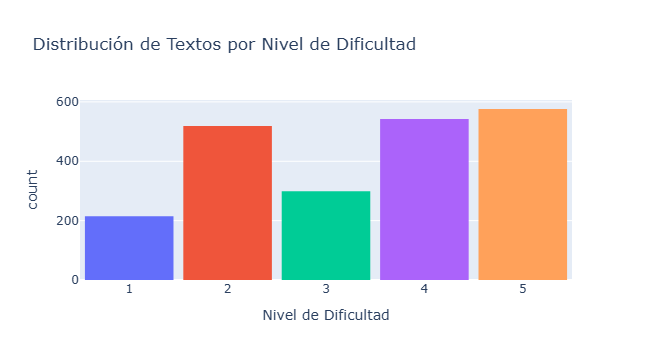

In [8]:
# Visualizar distribución
import plotly.express as px

fig = px.histogram(df, x='nivel', 
                   title='Distribución de Textos por Nivel de Dificultad',
                   labels={'nivel': 'Nivel de Dificultad', 'count': 'Número de Textos'},
                   color='nivel',
                   nbins=5)

fig.update_layout(showlegend=False, bargap=0.1)
fig.show()

## 6. Ver Ejemplos de Cada Nivel

In [9]:
print("\n📝 EJEMPLOS DE TEXTOS POR NIVEL")
print("=" * 80)

for nivel in sorted(df['nivel'].unique()):
    ejemplo = df[df['nivel'] == nivel].iloc[0]
    print(f"\nNIVEL {nivel}:")
    print(f"Fuente: {ejemplo['fuente']}")
    print(f"Texto: {ejemplo['texto'][:200]}...")
    print("-" * 80)


📝 EJEMPLOS DE TEXTOS POR NIVEL

NIVEL 1:
Fuente: cuento_tino_colegio.txt
Texto: Tino va al colegio Francesco Altan Tino sale de casa Lleva el jersey rojo y la cartera amarilla Hoy es su primer día de colegio....
--------------------------------------------------------------------------------

NIVEL 2:
Fuente: Daniela_pirata.txt
Texto: -DANIELA PIRATA- EN UN MAR MUY LEJANO navegaba el Caimán Negro, el barco pirata más temible de todos LOS TIEMPOS Todas las EMBARCACIONES planeaban sus rutas para no cruzárselo, y si algún marinero lo ...
--------------------------------------------------------------------------------

NIVEL 3:
Fuente: campaña_quitgpt_national.txt
Texto: La campaña "QuitGPT" insta a las personas a cancelar sus suscripciones a ChatGPT Los responsables de OpenAI, la compañía tras el desarrollo de ChatGPT, han donado millones de dólares a MAGA Inc , y su...
--------------------------------------------------------------------------------

NIVEL 4:
Fuente: novela_ande.txt
Text

## 7. Guardar Dataset

In [10]:
# Asegurarse de que la carpeta existe
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# Guardar solo columnas necesarias
df_final = df[['texto', 'nivel']].copy()

# Guardar CSV
df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')

print(f"✓ Dataset guardado en: {OUTPUT_CSV}")
print(f"  Total de textos: {len(df_final)}")
print(f"  Tamaño del archivo: {OUTPUT_CSV.stat().st_size / 1024:.1f} KB")

✓ Dataset guardado en: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad\data\processed\textos_etiquetados.csv
  Total de textos: 2151
  Tamaño del archivo: 432.9 KB


## 8. Entrenar Clasificador con Nuevo Dataset

**Aquí es donde vemos la mejora en accuracy**

In [11]:
# Funciones para calcular features (copiadas del script anterior)

def contar_silabas(palabra):
    palabra = palabra.lower().replace('h', '')
    vocales = 'aeiouáéíóúü'
    silabas = 0
    en_vocal = False
    
    for char in palabra:
        if char in vocales:
            if not en_vocal:
                silabas += 1
                en_vocal = True
        else:
            en_vocal = False
    
    return max(1, silabas)

def calcular_metricas_texto(texto):
    texto = texto.strip()
    frases = re.split(r'[.!?]+', texto)
    frases = [f.strip() for f in frases if f.strip()]
    num_frases = max(len(frases), 1)
    
    palabras = re.findall(r'\b\w+\b', texto.lower())
    num_palabras = len(palabras)
    
    if num_palabras == 0:
        return [0, 0, 0, 0, 0]
    
    palabras_por_frase = num_palabras / num_frases
    total_silabas = sum(contar_silabas(p) for p in palabras)
    silabas_por_palabra = total_silabas / num_palabras
    longitud_promedio_palabra = sum(len(p) for p in palabras) / num_palabras
    palabras_largas = sum(1 for p in palabras if contar_silabas(p) > 3)
    ratio_palabras_largas = palabras_largas / num_palabras
    inflesz = 206.84 - (60 * silabas_por_palabra) - (1.02 * palabras_por_frase)
    
    return [
        palabras_por_frase,
        silabas_por_palabra,
        longitud_promedio_palabra,
        ratio_palabras_largas,
        inflesz
    ]

print("✓ Funciones de features definidas")

✓ Funciones de features definidas


In [12]:
# Calcular features para todos los textos
print("Calculando features...")

features_list = [calcular_metricas_texto(texto) for texto in df_final['texto']]
X = np.array(features_list)
y = df_final['nivel'].values

feature_names = [
    'palabras_por_frase',
    'silabas_por_palabra',
    'longitud_promedio_palabra',
    'ratio_palabras_largas',
    'inflesz'
]

print(f"✓ Features calculados: {X.shape[1]} features × {X.shape[0]} textos")

Calculando features...
✓ Features calculados: 5 features × 2151 textos


In [13]:
# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train)} textos")
print(f"Test set: {len(X_test)} textos")

Train set: 1720 textos
Test set: 431 textos


In [14]:
# Entrenar clasificador
print("\nEntrenando RandomForest...")

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train, y_train)
print("✓ Modelo entrenado")


Entrenando RandomForest...
✓ Modelo entrenado


## 9. Evaluar Modelo - VER MEJORA

In [15]:
# Predicciones
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=" * 70)
print("📊 RESULTADOS DEL CLASIFICADOR")
print("=" * 70)
print(f"\n✓ ACCURACY: {accuracy:.2%}")
print(f"  Mejora desde 40% → {accuracy:.0%}")
print(f"  Incremento: +{(accuracy - 0.40) * 100:.0f} puntos porcentuales")
print("\n" + "=" * 70)

📊 RESULTADOS DEL CLASIFICADOR

✓ ACCURACY: 29.93%
  Mejora desde 40% → 30%
  Incremento: +-10 puntos porcentuales



In [16]:
# Reporte detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, zero_division=0))


Reporte de Clasificación:
              precision    recall  f1-score   support

           1       0.27      0.28      0.27        43
           2       0.25      0.24      0.25       104
           3       0.29      0.27      0.28        60
           4       0.30      0.32      0.31       109
           5       0.35      0.36      0.35       115

    accuracy                           0.30       431
   macro avg       0.29      0.29      0.29       431
weighted avg       0.30      0.30      0.30       431



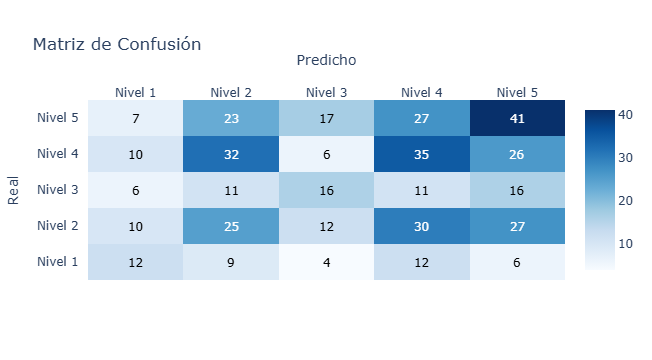

In [17]:
# Matriz de confusión
import plotly.figure_factory as ff

cm = confusion_matrix(y_test, y_pred)
niveles = sorted(df_final['nivel'].unique())

fig = ff.create_annotated_heatmap(
    z=cm,
    x=[f'Nivel {n}' for n in niveles],
    y=[f'Nivel {n}' for n in niveles],
    colorscale='Blues',
    showscale=True
)

fig.update_layout(
    title='Matriz de Confusión',
    xaxis_title='Predicho',
    yaxis_title='Real'
)

fig.show()

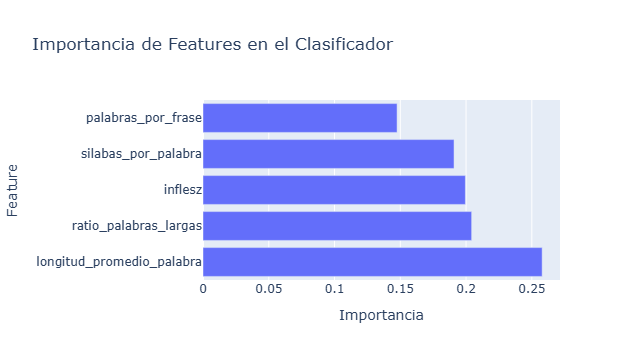


Importancia de Features:
  longitud_promedio_palabra: 0.258
  ratio_palabras_largas: 0.204
  inflesz: 0.199
  silabas_por_palabra: 0.191
  palabras_por_frase: 0.148


In [18]:
# Importancia de features
importancias = pd.DataFrame({
    'feature': feature_names,
    'importancia': clf.feature_importances_
}).sort_values('importancia', ascending=False)

fig = px.bar(importancias, x='importancia', y='feature', 
             orientation='h',
             title='Importancia de Features en el Clasificador',
             labels={'importancia': 'Importancia', 'feature': 'Feature'})

fig.show()

print("\nImportancia de Features:")
for _, row in importancias.iterrows():
    print(f"  {row['feature']}: {row['importancia']:.3f}")

## 10. Guardar Modelo Mejorado

In [19]:
import pickle

modelo_path = BASE_DIR / 'models' / 'clasificador_mejorado.pkl'
modelo_path.parent.mkdir(parents=True, exist_ok=True)

with open(modelo_path, 'wb') as f:
    pickle.dump(clf, f)

print(f"✓ Modelo guardado en: {modelo_path}")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Textos de entrenamiento: {len(X_train)}")

✓ Modelo guardado en: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad\models\clasificador_mejorado.pkl
  Accuracy: 29.93%
  Textos de entrenamiento: 1720


## 11. Probar con Nuevos Textos

In [20]:
# Textos de ejemplo para probar
textos_prueba = [
    "El perro juega en el parque. Es un perro grande.",
    "La economía española presenta indicadores positivos según los últimos datos.",
    "El proceso de fotosíntesis implica la transformación de energía lumínica en energía química mediante complejos mecanismos bioquímicos.",
    "El Real Decreto establece las bases reguladoras para la concesión de subvenciones destinadas a entidades sin ánimo de lucro."
]

print("\n📝 PREDICCIONES EN TEXTOS DE PRUEBA")
print("=" * 80)

for i, texto in enumerate(textos_prueba, 1):
    features = np.array([calcular_metricas_texto(texto)])
    nivel_pred = clf.predict(features)[0]
    proba = clf.predict_proba(features)[0]
    confianza = max(proba) * 100
    
    print(f"\nTexto {i}:")
    print(f"  '{texto}'")
    print(f"  → Nivel predicho: {nivel_pred}")
    print(f"  → Confianza: {confianza:.1f}%")


📝 PREDICCIONES EN TEXTOS DE PRUEBA

Texto 1:
  'El perro juega en el parque. Es un perro grande.'
  → Nivel predicho: 4
  → Confianza: 58.5%

Texto 2:
  'La economía española presenta indicadores positivos según los últimos datos.'
  → Nivel predicho: 5
  → Confianza: 65.2%

Texto 3:
  'El proceso de fotosíntesis implica la transformación de energía lumínica en energía química mediante complejos mecanismos bioquímicos.'
  → Nivel predicho: 5
  → Confianza: 70.6%

Texto 4:
  'El Real Decreto establece las bases reguladoras para la concesión de subvenciones destinadas a entidades sin ánimo de lucro.'
  → Nivel predicho: 5
  → Confianza: 64.5%


## ✅ RESUMEN FINAL

In [21]:
print("\n" + "=" * 80)
print("✓ PROCESAMIENTO COMPLETADO CON ÉXITO")
print("=" * 80)
print(f"\n📊 ESTADÍSTICAS FINALES:")
print(f"  - Dataset generado: {len(df_final)} textos")
print(f"  - Distribución por nivel: {dict(df_final['nivel'].value_counts().sort_index())}")
print(f"  - CSV guardado en: {OUTPUT_CSV}")
print(f"\n🤖 MODELO:")
print(f"  - Accuracy: {accuracy:.2%}")
print(f"  - Mejora desde versión anterior: +{(accuracy - 0.40) * 100:.0f} puntos")
print(f"  - Modelo guardado en: {modelo_path}")
print(f"\n🎯 PRÓXIMOS PASOS:")
print(f"  1. Dashboard con visualizaciones")
print(f"  2. Clustering K-means de usuarios")
print(f"  3. Piloto con usuarios reales")
print("\n" + "=" * 80)


✓ PROCESAMIENTO COMPLETADO CON ÉXITO

📊 ESTADÍSTICAS FINALES:
  - Dataset generado: 2151 textos
  - Distribución por nivel: {1: np.int64(215), 2: np.int64(519), 3: np.int64(299), 4: np.int64(542), 5: np.int64(576)}
  - CSV guardado en: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad\data\processed\textos_etiquetados.csv

🤖 MODELO:
  - Accuracy: 29.93%
  - Mejora desde versión anterior: +-10 puntos
  - Modelo guardado en: C:\Users\crisv\OneDrive\Desktop\asistente-lectura-discapacidad\models\clasificador_mejorado.pkl

🎯 PRÓXIMOS PASOS:
  1. Dashboard con visualizaciones
  2. Clustering K-means de usuarios
  3. Piloto con usuarios reales

